# ***SCRIPT PARA EL CALCULO SEGUN LA TEORIA DE PERFILES DELGADOS***
En este script se calculan varios parametros siguiendo la analogia del perfil deformable como una viga en voladizo y aplicando la teoria de perfiles delgados.
En este script también se realizan los calculos para la comparación de resultados reales vs resultados teoricos.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import math

#-------------------------------------------------------------------
# FUNCIONES NECESARIAS A LO LARGO DEL SCRIPT
#-------------------------------------------------------------------


def integrate(x, f):
    res = 0
    for i in range(len(x) - 1):
        dx = x[i + 1] - x[i]
        res += 0.5 * (f[i] + f[i + 1]) * dx
    return res

def airfoil_characteristics(alpha, Vinf, x, dzdx):
    alpha = alpha / 180 * math.pi
    c=x[-1]
    theta = np.arccos(1.0 - 2.0*x/c)

    num_coeficientes = 15
    A = np.zeros(num_coeficientes)
    A[0] =  alpha - (1/np.pi) * integrate(theta, dzdx)
    for i in range(1, len(A)):
        A[i] = (2/np.pi)*integrate(theta, np.multiply(dzdx, np.cos(i * theta)))

    gamma = np.zeros(len(theta))
    for i in range(1, len(theta)):
        gamma[i] =  A[0]* ((1+ math.cos(theta[i])) / ( math.sin(theta[i])))
        for j in range(1, len(A)):
            gamma[i]= gamma[i] + A[j] * math.sin(j * theta[i])
    gamma = 2 * Vinf * gamma

    cl = math.pi *(2*A[0]+A[1])
    cm_c4 = math.pi  / 4 *(A[2]-A[1])
    if cl != 0:
        x_cp = 1 /4 *(1 + math.pi/cl * (A[1]-A[2]))
    else:
        x_cp = np.nan

    return theta, gamma, cl, cm_c4, x_cp

def generate_cantilever_beam_data(L1, L2, L3, flex_factor, num_points_per_section=100):
    x1 = np.linspace(0, L1, num_points_per_section, endpoint=True)
    y1 = np.zeros_like(x1)
    dzdx1 = np.zeros_like(x1)

    x2_prime = np.linspace(0, L2, num_points_per_section, endpoint=True)
    x2 = x2_prime + L1
    y_flex_relative = -flex_factor * x2_prime**2 / 2
    dzdx_flex_relative = -flex_factor * x2_prime
    y2 = y_flex_relative
    dzdx2 = dzdx_flex_relative

    y_at_end_L2 = y_flex_relative[-1]
    dzdx_at_end_L2 = dzdx_flex_relative[-1]

    x3_prime_completo = np.linspace(0, L3, num_points_per_section, endpoint=True)
    dx3 = x3_prime_completo[1] - x3_prime_completo[0]

    x3_prime = np.linspace(dx3, L3, num_points_per_section - 1, endpoint=True)
    x3 = x3_prime + L1 + L2

    y3 = y_at_end_L2 + dzdx_at_end_L2 * x3_prime
    dzdx3 = np.full_like(x3, dzdx_at_end_L2)

    x_combined = np.concatenate((x1, x2, x3))
    y_combined = np.concatenate((y1, y2, y3))
    dzdx_combined = np.concatenate((dzdx1, dzdx2, dzdx3))

    sort_indices = np.argsort(x_combined)
    x_beam = x_combined[sort_indices]
    y_beam = y_combined[sort_indices]
    dzdx_beam = dzdx_combined[sort_indices]

    c_beam = L1 + L2 + L3
    return x_beam, y_beam, dzdx_beam, c_beam
    # --- PARÁMETRO DE ENVERGADURA FINITA ---
import numpy as np
import matplotlib.pyplot as plt
import math

# =============================================================================
# --- PARÁMETROS DE ENVERGADURA FINITA ---
# =============================================================================
AR_ala = 1      # Relación de aspecto (Alargamiento) de tu ala experimental
e_oswald = 0.9     # Factor de eficiencia de Oswald (típicamente entre 0.85 y 0.95 para alas rectangulares)

def corregir_cl_lineal_3D(cl_2d, AR):
    """
    Aplica la corrección modificando la pendiente de forma global.
    Mantiene la linealidad de las gráficas (líneas rectas).
    """
    # Pendiente teórica ideal 2D (Teoría de perfiles delgados: a0 = 2 * pi)
    a0 = 2 * math.pi
    e_oswald = 0.9     # Factor de eficiencia de Oswald (típicamente entre 0.85 y 0.95 para alas rectangulares)
    # Pendiente corregida para ala 3D según la línea sustentadora de Prandtl
    a_3d = a0 / (1.0 + a0 / (math.pi * AR * e_oswald))

    # Factor de reducción constante
    factor_reduccion = a_3d / a0

    # Al multiplicar por un factor fijo, la relación sigue siendo puramente lineal
    cl_3d_lineal = cl_2d * factor_reduccion
    return cl_3d_lineal

# =============================================================================
# --- FUNCIONES AUXILIARES DE CÁLCULO  ---
# =============================================================================

def calculate_theoretical_cl_for_angles_3D(angles, L1, L2, L3, num_points_per_section, alpha, Vinf, AR):
    cl_theoretical_values_3d = []
    for angle in angles:
        k = k_from_angle(angle)

        # Generar geometría de la viga
        x_beam_current, y_beam_current, dzdx_beam_current, c_beam_current = generate_cantilever_beam_data(
            L1, L2, L3, k, num_points_per_section
        )
        x_profile_normalized_for_theory = x_beam_current - x_beam_current.min()
        dzdx_profile = dzdx_beam_current

        # Calcular características 2D (Teoría de perfiles delgados original)
        _, _, cl_theory_2d, _, _ = airfoil_characteristics(
            alpha, Vinf, x_profile_normalized_for_theory, dzdx_profile
        )

        # APLICACIÓN DE LA CORRECCIÓN LINEAL 3D
        cl_theory_3d = corregir_cl_lineal_3D(cl_theory_2d, AR=AR)
        cl_theoretical_values_3d.append(cl_theory_3d)

    return np.array(cl_theoretical_values_3d)


def calculate_theoretical_cl_for_fixed_k_3D(fixed_k, angles_of_attack, L1, L2, L3, num_points_per_section, Vinf, AR):
    cl_theoretical_values_3d = []
    for current_alpha in angles_of_attack:
        # Generar geometría de la viga
        x_beam_current, y_beam_current, dzdx_beam_current, c_beam_current = generate_cantilever_beam_data(
            L1, L2, L3, fixed_k, num_points_per_section
        )
        x_profile_normalized_for_theory = x_beam_current - x_beam_current.min()
        dzdx_profile = dzdx_beam_current

        # Cl Teórico original (2D)
        _, _, cl_theory_2d, _, _ = airfoil_characteristics(
            current_alpha, Vinf, x_profile_normalized_for_theory, dzdx_profile
        )

        # APLICACIÓN DE LA CORRECCIÓN LINEAL 3D
        cl_theory_3d = corregir_cl_lineal_3D(cl_theory_2d, AR=AR)
        cl_theoretical_values_3d.append(cl_theory_3d)

    return np.array(cl_theoretical_values_3d)

### Modelado de la Viga en Voladizo
Se ha modelado la geometría del perfil delgado como una viga en voladizo con tres tramos:
- **Primer tramo (0 a 7.8 cm):** Fijo, sin flexión.
- **Segundo tramo (7.8 a 16.8 cm):** Flexible, con una flexión parabólica controlada por un factor de flexión (`flex_factor`).
- **Tercer tramo (16.8 a 20 cm):** Recto, continuando con la pendiente del final del segundo tramo.

Longitud de cuerda total de la viga: 20.000 cm
Rango de x: [0.000, 20.000] cm
Rango de y (camber): [-1.732, 0.000] cm


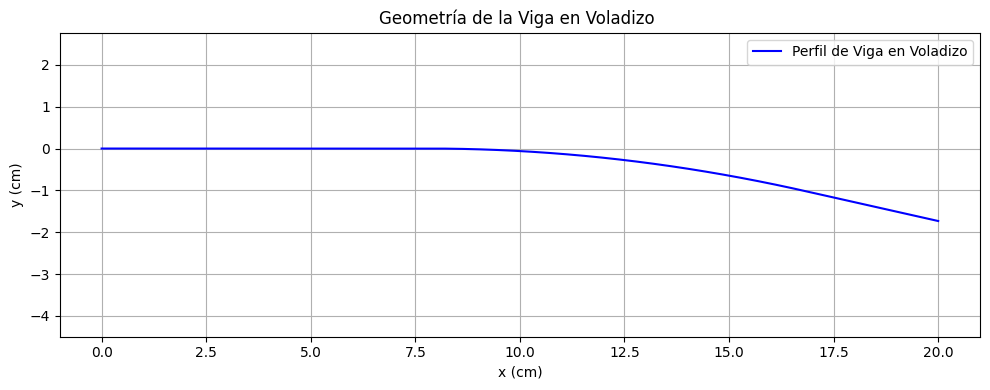

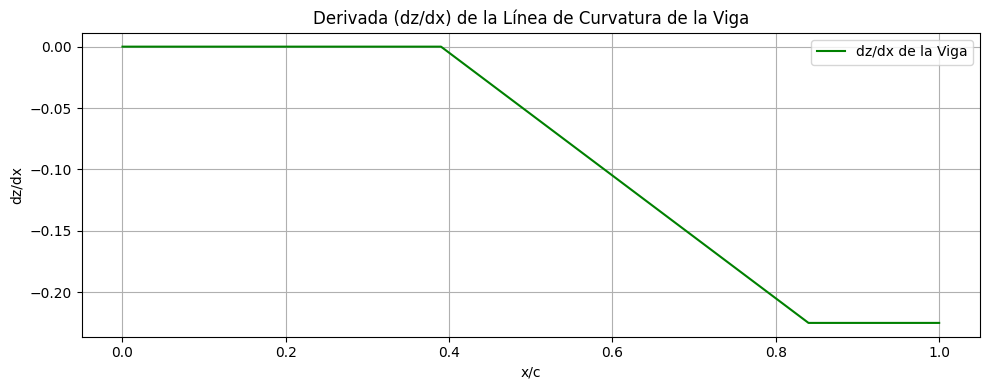

In [62]:
# --- Definición de parámetros de la viga ---
L1_beam = 7.8  # cm
L2_beam = 9    # cm
L3_beam = 3.2  # cm
flex_factor_beam = 0.025
num_points = 200

# Generar los datos corregidos
x_beam, y_beam, dzdx_beam, c_beam = generate_cantilever_beam_data(
    L1_beam, L2_beam, L3_beam, flex_factor_beam, num_points_per_section=num_points//3
)

print(f"Longitud de cuerda total de la viga: {c_beam:.3f} cm")
print(f"Rango de x: [{x_beam.min():.3f}, {x_beam.max():.3f}] cm")
print(f"Rango de y (camber): [{y_beam.min():.3f}, {y_beam.max():.3f}] cm")

# Gráfico del perfil de la viga (Verás que el quiebre ha desaparecido)
plt.figure(figsize=(10, 4))
plt.plot(x_beam, y_beam, 'b-', label='Perfil de Viga en Voladizo')
plt.title('Geometría de la Viga en Voladizo ')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

# Gráfico de la pendiente dzdx
plt.figure(figsize=(10, 4))
plt.plot(x_beam / c_beam, dzdx_beam, 'g-', label='dz/dx de la Viga')
plt.title('Derivada (dz/dx) de la Línea de Curvatura de la Viga')
plt.xlabel('x/c')
plt.ylabel('dz/dx')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de la Viga en Voladizo con Teoría de Perfiles Delgados

Longitud de cuerda calculada para la viga: 20.000 cm

Resultados para la Viga a alpha = 0 grados:
Cl = 1.0188
Cm (c/4) = -0.1274
x_cp (x/c) = 0.3750


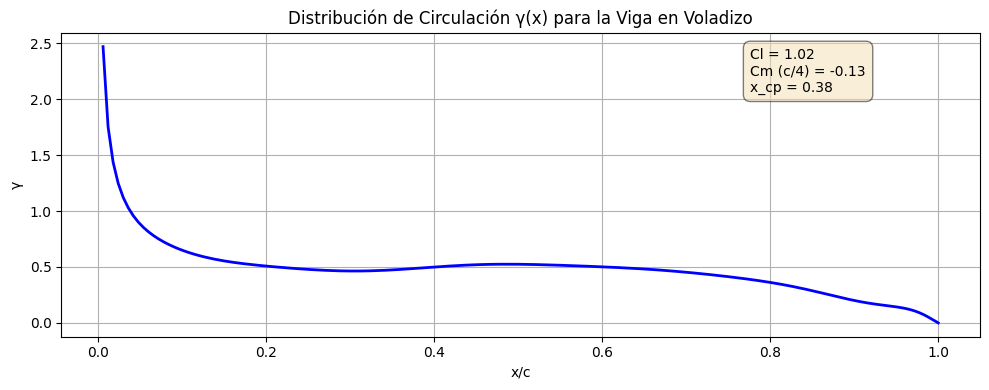

In [63]:
# Usar los datos de viga generados
# x_beam, y_beam, dzdx_beam, c_beam deberían estar disponibles de la ejecución de la celda anterior

if 'x_beam' in locals() and 'y_beam' in locals() and 'dzdx_beam' in locals() and 'c_beam' in locals():
    # 1. Obtener x e y del perfil de la viga y su dzdx
    x_profile = x_beam
    y_profile = y_beam
    dzdx_profile = dzdx_beam

    # 2. Definir la cuerda (c)
    c_profile = c_beam
    print(f"Longitud de cuerda calculada para la viga: {c_profile:.3f} cm")

    # 3. Definir ángulo de ataque y velocidad
    alpha_beam = 0 # ángulo de ataque en grados
    Vinf_beam = 1 # velocidad en m/s

    # 4. Llamar a la función airfoil_characteristics con los datos de la viga
    # La función airfoil_characteristics espera 'x' normalizado (0 a c) para algunos cálculos internos.
    # El x_beam ya está comenzando en 0, lo cual es adecuado.
    x_profile_normalized_for_theory = x_profile - x_profile.min()

    [theta, gamma_profile, cl_profile, cm_c4_profile, x_cp_profile] = airfoil_characteristics(alpha_beam, Vinf_beam, x_profile_normalized_for_theory, dzdx_profile)

    # 5. Imprimir Cl y la distribución de circulación
    print(f"\nResultados para la Viga a alpha = {alpha_beam} grados:")
    print(f"Cl = {cl_profile:.4f}")
    print(f"Cm (c/4) = {cm_c4_profile:.4f}")
    print(f"x_cp (x/c) = {x_cp_profile:.4f}")

    plt.figure(figsize=(10, 4))
    # Plotear gamma contra x/c (x normalizado)
    plt.plot(x_profile_normalized_for_theory[1:] / c_profile, gamma_profile[1:], 'b-', linewidth=2)
    plt.title("Distribución de Circulación γ(x) para la Viga en Voladizo")
    plt.xlabel("x/c")
    plt.ylabel("γ")
    plt.grid(True)

    # Añadir Cl, Cm, x_cp al gráfico como anotación de texto
    textstr = f'Cl = {cl_profile:.2f}\nCm (c/4) = {cm_c4_profile:.2f}\nx_cp = {x_cp_profile:.2f}'
    props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5)
    plt.text(0.75, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

else:
    print("Las variables de la viga necesarias para el análisis no están definidas. Por favor, asegúrate de haber ejecutado la celda anterior que genera la geometría de la viga.")

### Análisis de Coeficiente de Presión (Cp) para Diferentes Momentos de Flexión

Ahora, vamos a visualizar el coeficiente de presión a lo largo de la cuerda (`x/c`) para diferentes factores de flexión aplicados a la viga en voladizo. Esto nos permitirá entender cómo la deformación del perfil afecta la distribución de presiones, manteniendo el ángulo de ataque constante.

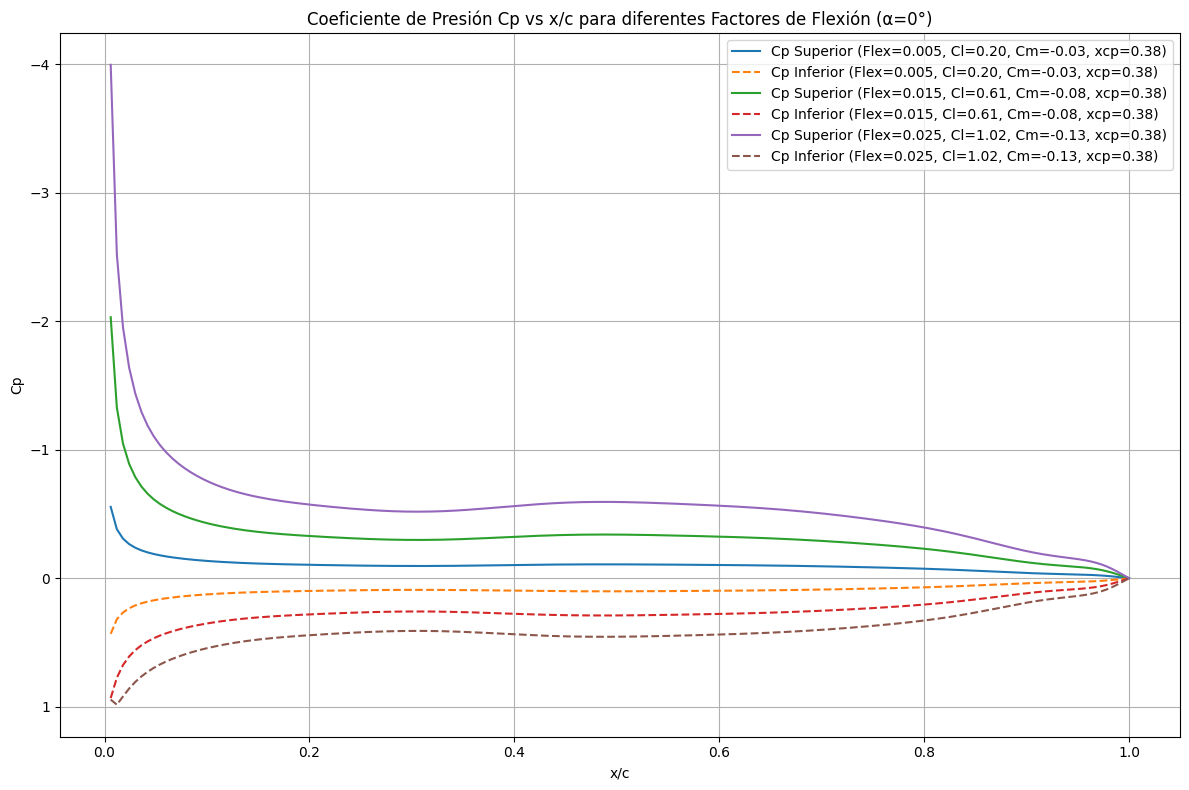

In [64]:
def plot_cp_for_different_flex_factors(flex_factor_list, alpha_val, Vinf, L1, L2, L3, num_points_per_section):
    """
    Calcula y grafica el coeficiente de presión (Cp) vs x/c para una lista de factores de flexión.

    Args:
        flex_factor_list (list): Lista de factores de flexión a simular.
        alpha_val (float): Ángulo de ataque constante en grados.
        Vinf (float): Velocidad de la corriente libre.
        L1 (float): Longitud de la primera sección fija (cm).
        L2 (float): Longitud de la segunda sección flexible (cm).
        L3 (float): Longitud de la tercera sección recta (cm).
        num_points_per_section (int): Número de puntos por sección para la generación de la viga.
    """
    plt.figure(figsize=(12, 8))
    for flex_factor in flex_factor_list:
        # Genera los datos de la viga para el factor de flexión actual
        x_beam_current, y_beam_current, dzdx_beam_current, c_beam_current = generate_cantilever_beam_data(L1, L2, L3, flex_factor, num_points_per_section)

        # Prepara los datos para la función airfoil_characteristics
        x_profile_normalized_for_theory = x_beam_current - x_beam_current.min()
        dzdx_profile = dzdx_beam_current
        c_profile = c_beam_current

        # Obtiene las características aerodinámicas para el factor de flexión actual (a alfa constante)
        theta, gamma, cl, cm_c4, x_cp = airfoil_characteristics(alpha_val, Vinf, x_profile_normalized_for_theory, dzdx_profile)

        # Calcula los valores de Cp
        # Se salta el primer punto (borde de ataque) debido a la singularidad en el cálculo de gamma
        Cp_upper = 1 - (1 + gamma[1:] / (2 * Vinf))**2
        Cp_lower = 1 - (1 - gamma[1:] / (2 * Vinf))**2

        # Coordenadas x correspondientes a gamma[1:], normalizadas por la longitud de la cuerda
        x_plot_normalized = x_profile_normalized_for_theory[1:] / c_profile

        plt.plot(x_plot_normalized, Cp_upper, label=f'Cp Superior (Flex={flex_factor}, Cl={cl:.2f}, Cm={cm_c4:.2f}, xcp={x_cp:.2f})')
        plt.plot(x_plot_normalized, Cp_lower, '--', label=f'Cp Inferior (Flex={flex_factor}, Cl={cl:.2f}, Cm={cm_c4:.2f}, xcp={x_cp:.2f})')

    plt.title(f"Coeficiente de Presión Cp vs x/c para diferentes Factores de Flexión (α={alpha_val}°)")
    plt.xlabel("x/c")
    plt.ylabel("Cp")
    plt.grid(True)
    plt.legend()
    plt.gca().invert_yaxis() # Invierte el eje y para seguir la convención aerodinámica (Cp más negativo hacia arriba)
    plt.tight_layout()
    plt.show()

# --- Definir parámetros para la nueva gráfica ---
flex_factors_to_plot = [0.005, 0.015, 0.025] # Lista de factores de flexión a probar
alpha_for_flex_plot = 0 # Ángulo de ataque constante para este gráfico
Vinf_plot = Vinf_beam if 'Vinf_beam' in locals() else 1 # Usa Vinf existente o por defecto 1

# Usa los parámetros de la viga definidos previamente en generate_cantilever_beam_data (celda 57ca2d48)
L1_plot = L1_beam if 'L1_beam' in locals() else 7.8
L2_plot = L2_beam if 'L2_beam' in locals() else 9
L3_plot = L3_beam if 'L3_beam' in locals() else 3
num_points_plot = num_points if 'num_points' in locals() else 500
num_points_per_section_plot = num_points_plot // 3

# Llama a la nueva función de graficado
plot_cp_for_different_flex_factors(flex_factors_to_plot, alpha_for_flex_plot, Vinf_plot, L1_plot, L2_plot, L3_plot, num_points_per_section_plot)

# ANALISIS DE LOS RESULTADOS EXPERIMENTALES

VARIACION DE LA CURVATURA DEL PERFIL PARA ANGULO DE ATAQUE FIJO

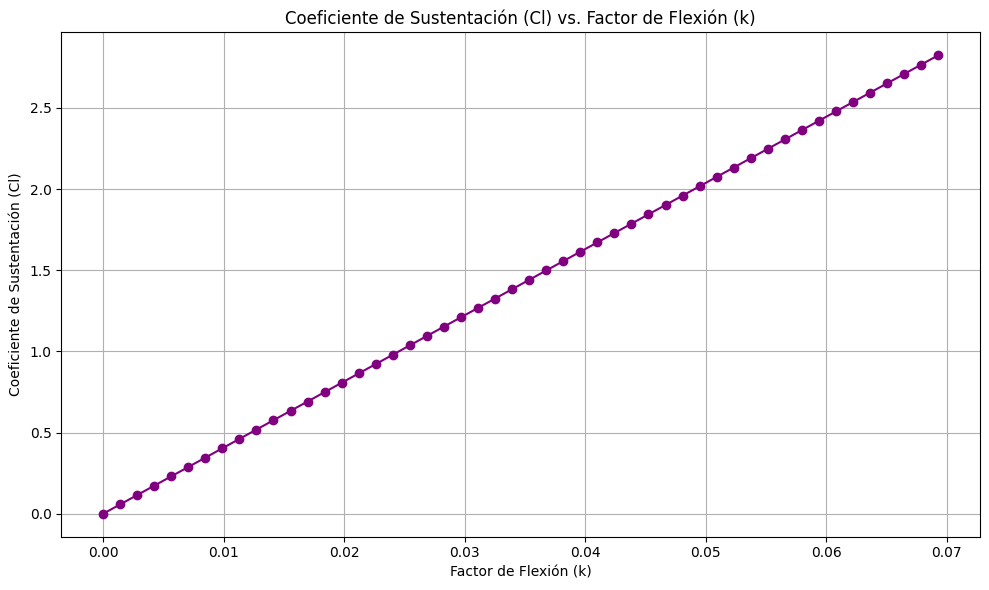

In [65]:
flex_factors_k = np.linspace(0, 0.0693, 50) # Generar 50 puntos entre 0 y 0.0693
cl_values = []

# Reutilizar parámetros de celdas anteriores
L1 = L1_beam
L2 = L2_beam
L3 = L3_beam
num_points_per_section = num_points // 3
alpha = alpha_beam
Vinf = Vinf_beam

for k in flex_factors_k:
    # Generar datos de la viga para el factor de flexión actual
    x_beam_current, y_beam_current, dzdx_beam_current, c_beam_current = generate_cantilever_beam_data(
        L1, L2, L3, k, num_points_per_section
    )

    # Preparar datos para la función airfoil_characteristics
    x_profile_normalized_for_theory = x_beam_current - x_beam_current.min()
    dzdx_profile = dzdx_beam_current

    # Calcular características del perfil aerodinámico
    theta, gamma, cl, cm_c4, x_cp = airfoil_characteristics(
        alpha, Vinf, x_profile_normalized_for_theory, dzdx_profile
    )
    cl_values.append(cl)

# Graficado
plt.figure(figsize=(10, 6))
plt.plot(flex_factors_k, cl_values, 'o-', color='purple')
plt.title('Coeficiente de Sustentación (Cl) vs. Factor de Flexión (k)')
plt.xlabel('Factor de Flexión (k)')
plt.ylabel('Coeficiente de Sustentación (Cl)')
plt.grid(True)
plt.tight_layout()
plt.show()

--- COEFICIENTES DE SUSTENTACIÓN (CL) CALCULADOS ---
Para v = 5.4 m/s: [0.     0.     0.14   0.154  0.196  0.21   0.5599 0.6859 0.6999 0.7279
 0.7559]
Para v = 8.6 m/s: [0.     0.     0.     0.1656 0.3146 0.3863 0.4967 0.6622]
Para v = 4.1 m/s: [0.     0.     0.0728 0.0486 0.1214 0.1942 0.3399 0.4371 0.5827]


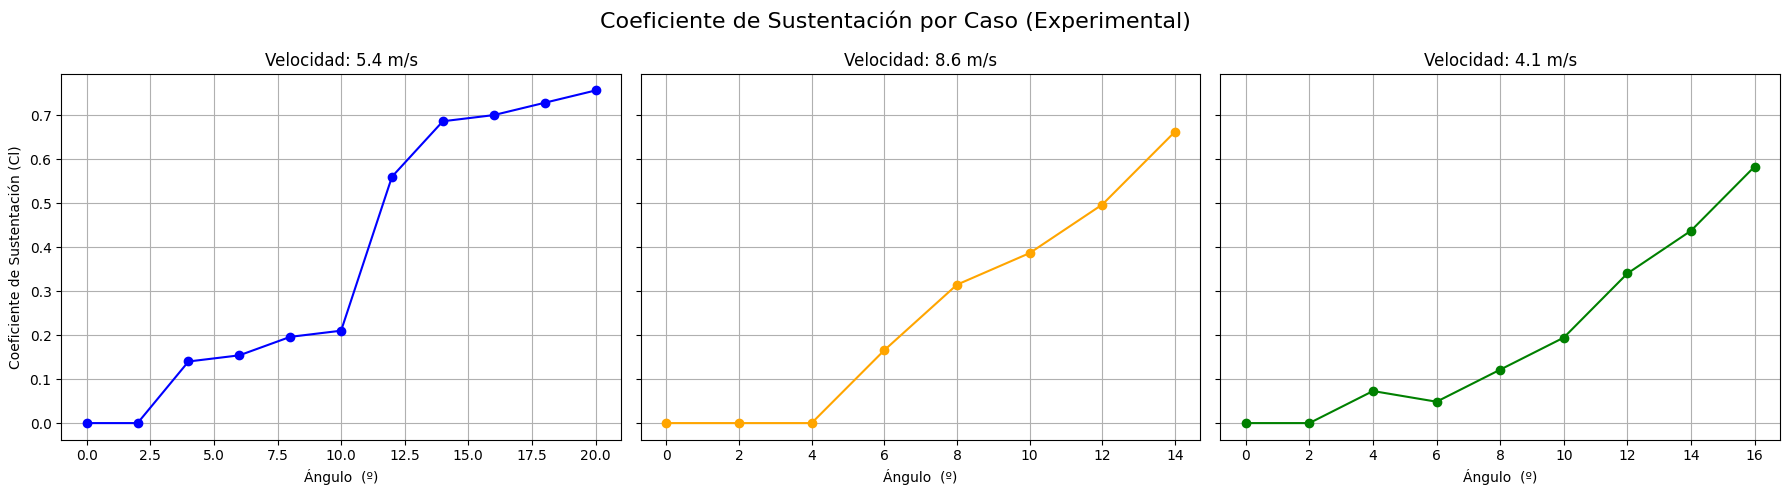

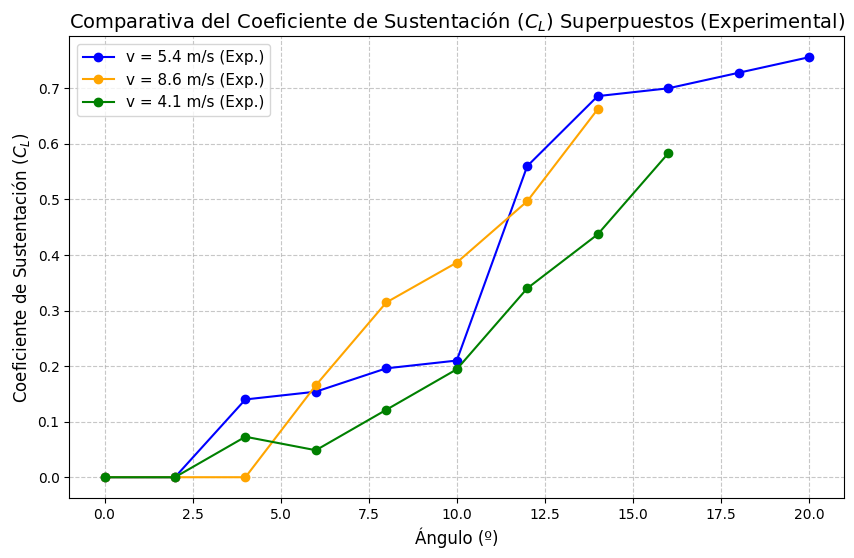

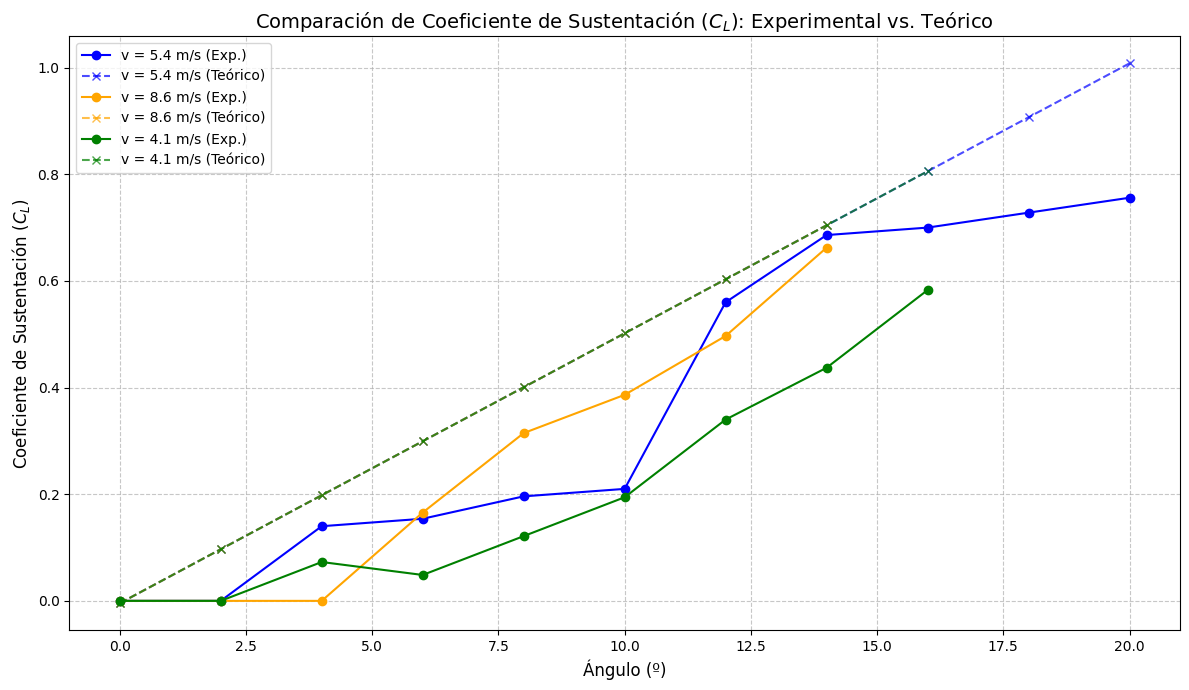

In [66]:
# --- CONFIGURACIÓN DE PARÁMETROS DEL EXPERIMENTO ---
s = 0.20*0.20 # Cuerda del NACA 0015 en metros (20 cm)

rho = 1.225  # Densidad del aire estándar (kg/m^3)

# --- DATOS DE LA TABLA ---
# Ángulos (Servo)
angulos_54 = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
angulos_86 = np.array([0, 2, 4, 6, 8, 10, 12, 14])
angulos_41 = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16])

# Fuerzas de Sustentación (L) en Newtons
fuerza_54 = np.array([0, 0, 0.1, 0.11, 0.14, 0.15, 0.4, 0.49, 0.5, 0.52, 0.54])
fuerza_86 = np.array([0, 0, 00, 0.3, 0.57, 0.7, 0.9, 1.2])
fuerza_41 = np.array([0, 0, 0.03, 0.02, 0.05, 0.08, 0.14, 0.18, 0.24])

# Velocidades (v)
v_54 = 5.4
v_86 = 8.6
v_41 = 4.1


# --- FUNCIÓN PARA CALCULAR CL ---
def calcular_cl(fuerza, velocidad, rho, s):
    dinamica = 0.5 * rho * (velocidad**2) * s
    return fuerza / dinamica


# Calcular coeficientes experimentales
cl_54 = calcular_cl(fuerza_54, v_54, rho, s)
cl_86 = calcular_cl(fuerza_86, v_86, rho, s)
cl_41 = calcular_cl(fuerza_41, v_41, rho, s)

# --- IMPRESIÓN DE RESULTADOS EN CONSOLA ---
print("--- COEFICIENTES DE SUSTENTACIÓN (CL) CALCULADOS ---")
print(f"Para v = 5.4 m/s: {np.round(cl_54, 4)}")
print(f"Para v = 8.6 m/s: {np.round(cl_86, 4)}")
print(f"Para v = 4.1 m/s: {np.round(cl_41, 4)}")

# --- GRÁFICAS EXPERIMENTALES (CÓDIGO EXISTENTE) ---
# Figura 1: Tres gráficas una al lado de la otra (Subplots)
fig1, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfica 1 (5.4 m/s)
axs[0].plot(angulos_54, cl_54, "o-", color="blue", label="5.4 m/s")
axs[0].set_title("Velocidad: 5.4 m/s")
axs[0].set_xlabel("Ángulo  (º)")
axs[0].set_ylabel("Coeficiente de Sustentación (Cl)")
axs[0].grid(True)

# Gráfica 2 (8.6 m/s)
axs[1].plot(angulos_86, cl_86, "o-", color="orange", label="8.6 m/s")
axs[1].set_title("Velocidad: 8.6 m/s")
axs[1].set_xlabel("Ángulo  (º)")
axs[1].grid(True)

# Gráfica 3 (4.1 m/s)
axs[2].plot(angulos_41, cl_41, "o-", color="green", label="4.1 m/s")
axs[2].set_title("Velocidad: 4.1 m/s")
axs[2].set_xlabel("Ángulo  (º)")
axs[2].grid(True)

plt.suptitle("Coeficiente de Sustentación por Caso (Experimental)", fontsize=16)
plt.tight_layout()

# Figura 2: Tres gráficas superpuestas (CÓDIGO EXISTENTE)
plt.figure(figsize=(10, 6))
plt.plot(angulos_54, cl_54, "o-", color="blue", label="v = 5.4 m/s (Exp.)")
plt.plot(angulos_86, cl_86, "o-", color="orange", label="v = 8.6 m/s (Exp.)")
plt.plot(angulos_41, cl_41, "o-", color="green", label="v = 4.1 m/s (Exp.)")

plt.title(
    "Comparativa del Coeficiente de Sustentación ($C_L$) Superpuestos (Experimental)",
    fontsize=14,
)
plt.xlabel("Ángulo (º)", fontsize=12)
plt.ylabel("Coeficiente de Sustentación ($C_L$)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)

# --- CÁLCULO Y GRÁFICA DEL CL TEÓRICO SUPERPUESTO ---

# Definir la relación entre k y el ángulo
def k_from_angle(angle):
    return 0.004002 * angle -0.000350

# Parámetros teóricos de la viga (reutilizando de celdas previas, asumiendo que están definidos)
# Se recomienda que L1_beam, L2_beam, L3_beam, num_points, alpha_beam, Vinf_beam estén definidos
L1_beam_val = L1_beam
L2_beam_val = L2_beam
L3_beam_val = L3_beam
num_points_per_section_val = num_points // 3

# Calcular Cl teórico para cada set de ángulos experimentales
cl_theoretical_54 = calculate_theoretical_cl_for_angles_3D(angulos_54, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, alpha_beam, Vinf_beam, AR_ala)
cl_theoretical_86 = calculate_theoretical_cl_for_angles_3D(angulos_86, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, alpha_beam, Vinf_beam, AR_ala)
cl_theoretical_41 = calculate_theoretical_cl_for_angles_3D(angulos_41, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, alpha_beam, Vinf_beam, AR_ala)

# Nueva figura para superponer experimental y teórico
plt.figure(figsize=(12, 7))

# Plotear resultados para v = 5.4 m/s
plt.plot(angulos_54, cl_54, "o-", color="blue", label="v = 5.4 m/s (Exp.)")
plt.plot(angulos_54, cl_theoretical_54, "x--", color="blue", alpha=0.7, label="v = 5.4 m/s (Teórico)")

# Plotear resultados para v = 8.6 m/s
plt.plot(angulos_86, cl_86, "o-", color="orange", label="v = 8.6 m/s (Exp.)")
plt.plot(angulos_86, cl_theoretical_86, "x--", color="orange", alpha=0.7, label="v = 8.6 m/s (Teórico)")

# Plotear resultados para v = 4.1 m/s
plt.plot(angulos_41, cl_41, "o-", color="green", label="v = 4.1 m/s (Exp.)")
plt.plot(angulos_41, cl_theoretical_41, "x--", color="green", alpha=0.7, label="v = 4.1 m/s (Teórico)")

plt.title(
    "Comparación de Coeficiente de Sustentación ($C_L$): Experimental vs. Teórico",
    fontsize=14,
)
plt.xlabel("Ángulo (º)", fontsize=12)
plt.ylabel("Coeficiente de Sustentación ($C_L$)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

# Mostrar ambas ventanas de gráficas
plt.show()

VARIACION DEL ANGULO DE ATAQUE CON CURVATURA FIJA

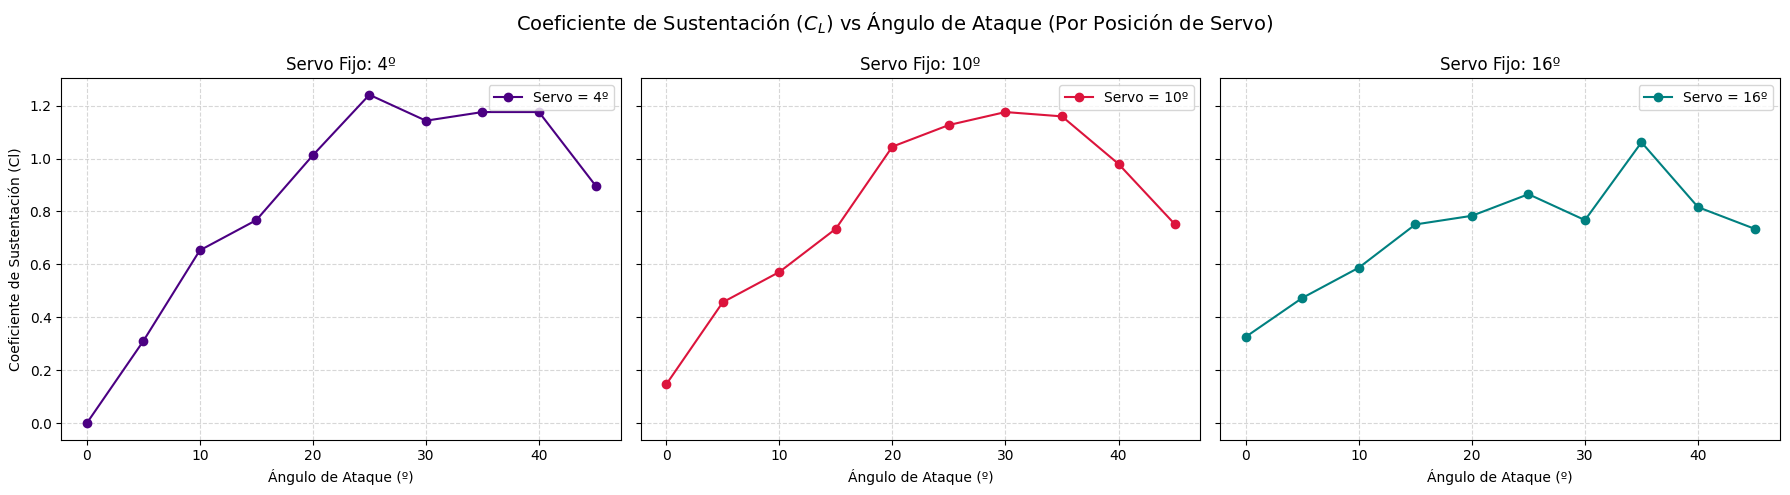

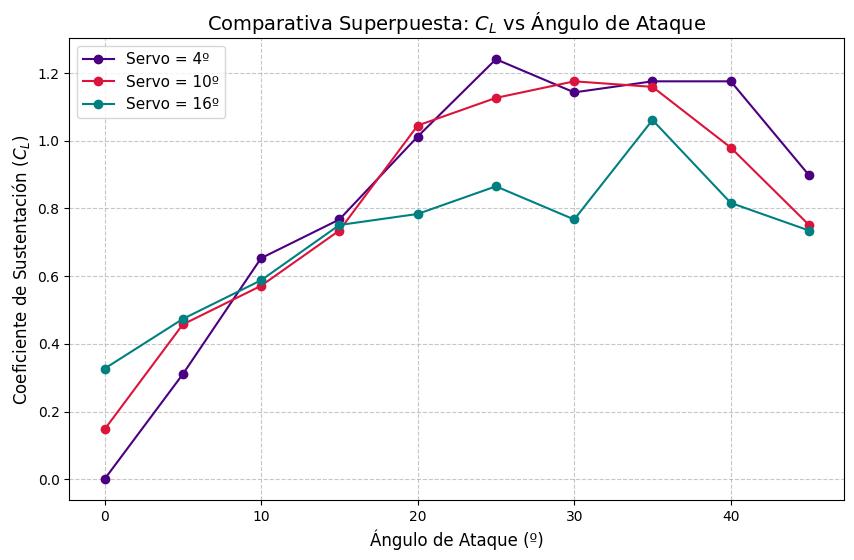

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN DE PARÁMETROS DEL EXPERIMENTO ---
cuerda = 0.20  # Cuerda del NACA 0015 en metros (20 cm)
envergadura = 0.20  # TODO: Ajusta el ancho/envergadura real de tu modelo en metros
S = cuerda * envergadura  # Superficie alar automática en m^2

rho = 1.225  # Densidad del aire estándar (kg/m^3)
v = 5.0  # Velocidad constante del viento para este ensayo (m/s)

# --- DATOS DE LA NUEVA TABLA ---
# Ángulos de ataque (Eje X común para todos los casos)
angulos_ataque = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])

# Fuerzas de Sustentación (LIFT) en Newtons para cada configuración del servo
# Usando los datos de sustentación proporcionados, re-interpretando a qué ángulo de servo corresponden
lift_4 = np.array([0.0, 0.19, 0.4, 0.47, 0.62, 0.76, 0.7, 0.72, 0.72, 0.55]) # Para Servo = 4º
lift_10 = np.array([0.09, 0.28, 0.35, 0.45, 0.64, 0.69, 0.72, 0.71, 0.6, 0.46]) # Para Servo = 10º (antes lift_6/lift_10_old)
lift_16 = np.array([0.2, 0.29, 0.36, 0.46, 0.48, 0.53, 0.47, 0.65, 0.5, 0.45]) # Para Servo = 16º (antes lift_10_new/lift_16_old)


# --- FUNCIÓN PARA CALCULAR CL ---
def calcular_cl(lift, velocidad, rho, superficie):
    presion_dinamica = 0.5 * rho * (velocidad**2) * superficie
    return lift / presion_dinamica


# Calcular coeficientes de sustentación
cl_4 = calcular_cl(lift_4, v, rho, S)
cl_10 = calcular_cl(lift_10, v, rho, S)
cl_16 = calcular_cl(lift_16, v, rho, S)

# --- FIGURA 1: Tres gráficas una al lado de la otra (Subplots) ---
fig1, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfica Servo = 4º
axs[0].plot(angulos_ataque, cl_4, "o-", color="indigo", label="Servo = 4º")
axs[0].set_title("Servo Fijo: 4º")
axs[0].set_xlabel("Ángulo de Ataque (º)")
axs[0].set_ylabel("Coeficiente de Sustentación (Cl)")
axs[0].grid(True, linestyle="--", alpha=0.5)
axs[0].legend()

# Gráfica Servo = 10º
axs[1].plot(angulos_ataque, cl_10, "o-", color="crimson", label="Servo = 10º")
axs[1].set_title("Servo Fijo: 10º")
axs[1].set_xlabel("Ángulo de Ataque (º)")
axs[1].grid(True, linestyle="--", alpha=0.5)
axs[1].legend()

# Gráfica Servo = 16º
axs[2].plot(angulos_ataque, cl_16, "o-", color="teal", label="Servo = 16º")
axs[2].set_title("Servo Fijo: 16º")
axs[2].set_xlabel("Ángulo de Ataque (º)")
axs[2].grid(True, linestyle="--", alpha=0.5)
axs[2].legend()

plt.suptitle(
    "Coeficiente de Sustentación ($C_L$) vs Ángulo de Ataque (Por Posición de Servo)",
    fontsize=14,
)
plt.tight_layout()

# --- FIGURA 2: Tres gráficas superpuestas ---
plt.figure(figsize=(10, 6))
plt.plot(angulos_ataque, cl_4, "o-", color="indigo", label="Servo = 4º")
plt.plot(angulos_ataque, cl_10, "o-", color="crimson", label="Servo = 10º")
plt.plot(angulos_ataque, cl_16, "o-", color="teal", label="Servo = 16º")

plt.title(
    "Comparativa Superpuesta: $C_L$ vs Ángulo de Ataque", fontsize=14
)
plt.xlabel("Ángulo de Ataque (º)", fontsize=12)
plt.ylabel("Coeficiente de Sustentación ($C_L$)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)

# Mostrar los gráficos en pantalla
plt.show()

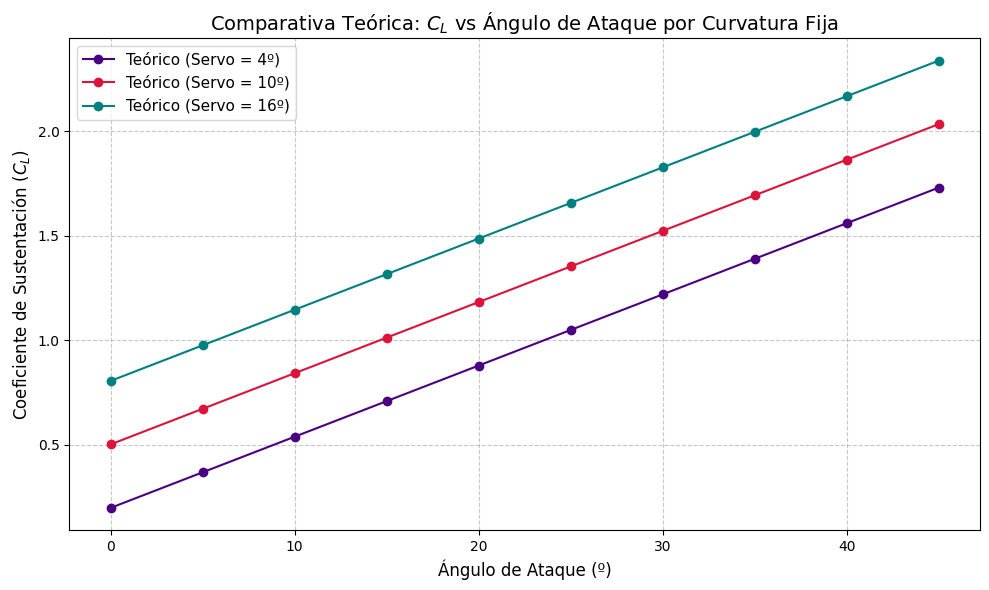

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Re-utilizando la función k_from_angle definida previamente (de la celda BbVyhrhzrphH)
def k_from_angle(angle):
    return 0.004002 * angle - 0.000350

# Parámetros para el modelo de viga en voladizo (re-utilizando de celdas anteriores)
L1_beam_val = locals().get('L1_beam', 7.8)
L2_beam_val = locals().get('L2_beam', 9)
L3_beam_val = locals().get('L3_beam', 3.2)
num_points_val = locals().get('num_points', 200)
num_points_per_section_val = num_points_val // 3
Vinf_theoretical = 1 # Asumiendo Vinf = 1 para cálculos teóricos no dimensionales

# Ángulos de ataque de los nuevos datos experimentales (de la celda qd8dvRfNr2ZA)
angulos_ataque = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])

# Definir los ángulos del servo para las 'curvaturas' (actualizado a 4, 10, 16)
servo_angles_for_curvatures = [4, 10, 16]


# Calcular Cl teórico para cada curvatura
cl_theoretical_servo_4 = calculate_theoretical_cl_for_fixed_k_3D(
    k_from_angle(servo_angles_for_curvatures[0]), angulos_ataque, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, Vinf_theoretical, AR_ala)

cl_theoretical_servo_10 = calculate_theoretical_cl_for_fixed_k_3D(
    k_from_angle(servo_angles_for_curvatures[1]), angulos_ataque, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, Vinf_theoretical, AR_ala)

cl_theoretical_servo_16 = calculate_theoretical_cl_for_fixed_k_3D(
    k_from_angle(servo_angles_for_curvatures[2]),angulos_ataque, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, Vinf_theoretical, AR_ala)

# Graficando las curvas teóricas de Cl
plt.figure(figsize=(10, 6))
plt.plot(angulos_ataque, cl_theoretical_servo_4, 'o-', color='indigo', label='Teórico (Servo = 4º)')
plt.plot(angulos_ataque, cl_theoretical_servo_10, 'o-', color='crimson', label='Teórico (Servo = 10º)')
plt.plot(angulos_ataque, cl_theoretical_servo_16, 'o-', color='teal', label='Teórico (Servo = 16º)')

plt.title('Comparativa Teórica: $C_L$ vs Ángulo de Ataque por Curvatura Fija', fontsize=14)
plt.xlabel('Ángulo de Ataque (º)', fontsize=12)
plt.ylabel('Coeficiente de Sustentación ($C_L$)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparativa Superpuesta: $C_L$ Experimental vs. $C_L$ Teórico por Curvatura Fija

Esta sección combina los resultados experimentales y teóricos en una única gráfica para facilitar la comparación de cómo la teoría de la viga en voladizo modela el comportamiento del coeficiente de sustentación bajo diferentes configuraciones de curvatura.

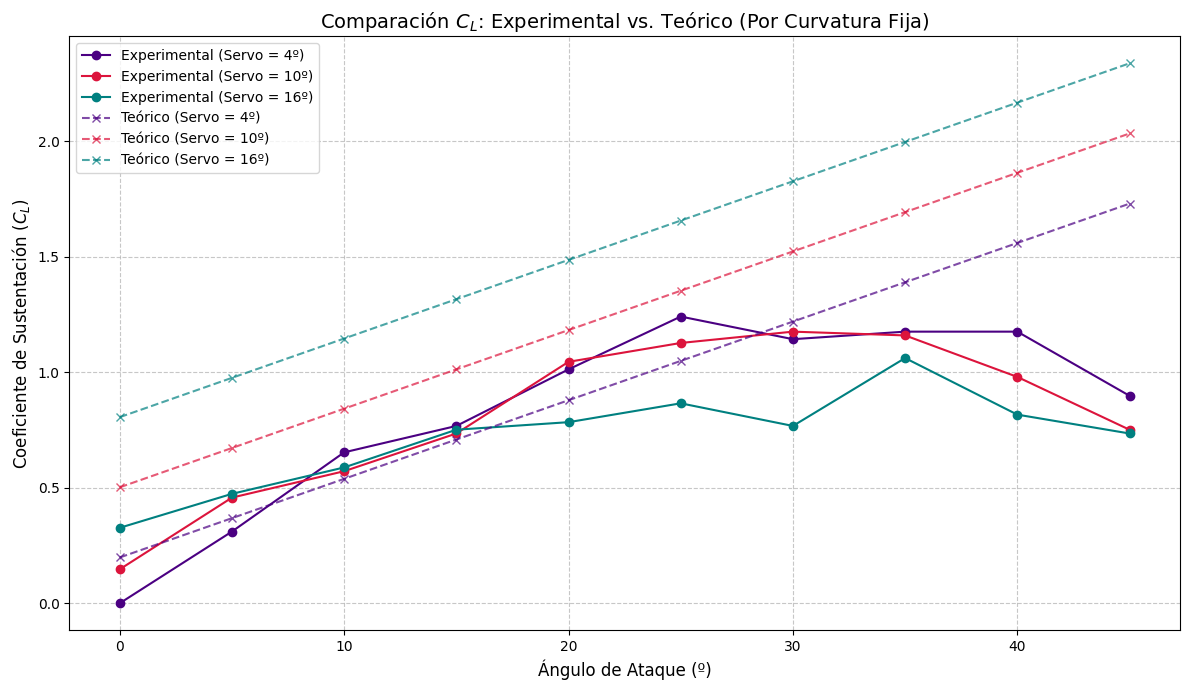

In [69]:
# Re-importar librerías necesarias (ya deberían estar cargadas, pero es buena práctica para celdas independientes)
import matplotlib.pyplot as plt
import numpy as np

# --- DATOS EXPERIMENTALES Y CÁLCULOS (re-utilizando la lógica de qd8dvRfNr2ZA) ---
# Parámetros de qd8dvRfNr2ZA
cuerda = 0.20  # Cuerda del NACA 0015 en metros (20 cm)
envergadura = 0.20  # Ancho/envergadura del modelo en metros
S = cuerda * envergadura  # Superficie alar automática en m^2
rho = 1.225  # Densidad del aire estándar (kg/m^3)
v_experimental_fixed = 5.0  # Velocidad constante del viento para este ensayo (m/s)

# Ángulos de ataque de los nuevos datos experimentales (de la celda qd8dvRfNr2ZA)
angulos_ataque_exp = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])

# Fuerzas de sustentación para cada configuración de servo (re-mapeado a nuevos ángulos de servo)
lift_exp_servo_4 = np.array([0.0, 0.19, 0.4, 0.47, 0.62, 0.76, 0.7, 0.72, 0.72, 0.55]) # Corresponde a lift_4 original
lift_exp_servo_10 = np.array([0.09, 0.28, 0.35, 0.45, 0.64, 0.69, 0.72, 0.71, 0.6, 0.46]) # Corresponde a lift_10 original
lift_exp_servo_16 = np.array([0.2, 0.29, 0.36, 0.46, 0.48, 0.53, 0.47, 0.65, 0.5, 0.45]) # Corresponde a lift_16 original

# Función para calcular Cl (de qd8dvRfNr2ZA)
def calcular_cl_experimental(lift, velocidad, rho, superficie):
    presion_dinamica = 0.5 * rho * (velocidad**2) * superficie
    return lift / presion_dinamica

# Calcular coeficientes de sustentación experimentales
cl_exp_servo_4 = calcular_cl_experimental(lift_exp_servo_4, v_experimental_fixed, rho, S)
cl_exp_servo_10 = calcular_cl_experimental(lift_exp_servo_10, v_experimental_fixed, rho, S)
cl_exp_servo_16 = calcular_cl_experimental(lift_exp_servo_16, v_experimental_fixed, rho, S)

# --- DATOS TEÓRICOS Y CÁLCULOS (re-utilizando la lógica de hhvVpOeYGIoE) ---
# Re-utilizando la función k_from_angle definida previamente
def k_from_angle(angle):
    return 0.004002 * angle - 0.000350

# Parámetros para el modelo de viga en voladizo (re-utilizando de celdas anteriores)
L1_beam_val = locals().get('L1_beam', 7.8)
L2_beam_val = locals().get('L2_beam', 9)
L3_beam_val = locals().get('L3_beam', 3.2)
num_points_val = locals().get('num_points', 200)
num_points_per_section_val = num_points_val // 3
Vinf_theoretical = 1 # Asumiendo Vinf = 1 para cálculos teóricos no dimensionales

# Ángulos de ataque para el cálculo teórico (igual que los experimentales)
angulos_ataque_theo = angulos_ataque_exp

# Definir los ángulos del servo para las 'curvaturas' (actualizado a 4, 10, 16)
servo_angles_for_curvatures = [4, 10, 16]

# Calcular Cl teórico para cada curvatura
cl_theoretical_servo_4 = calculate_theoretical_cl_for_fixed_k_3D(
    k_from_angle(servo_angles_for_curvatures[0]), angulos_ataque, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, Vinf_theoretical, AR_ala)

cl_theoretical_servo_10 = calculate_theoretical_cl_for_fixed_k_3D(
    k_from_angle(servo_angles_for_curvatures[1]), angulos_ataque, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, Vinf_theoretical, AR_ala)

cl_theoretical_servo_16 = calculate_theoretical_cl_for_fixed_k_3D(
    k_from_angle(servo_angles_for_curvatures[2]),angulos_ataque, L1_beam_val, L2_beam_val, L3_beam_val, num_points_per_section_val, Vinf_theoretical, AR_ala)

# --- GRAFICADO COMBINADO ---
plt.figure(figsize=(12, 7))

# Graficar datos experimentales
plt.plot(angulos_ataque_exp, cl_exp_servo_4, 'o-', color='indigo', label='Experimental (Servo = 4º)')
plt.plot(angulos_ataque_exp, cl_exp_servo_10, 'o-', color='crimson', label='Experimental (Servo = 10º)')
plt.plot(angulos_ataque_exp, cl_exp_servo_16, 'o-', color='teal', label='Experimental (Servo = 16º)')

# Graficar datos teóricos
plt.plot(angulos_ataque_theo, cl_theoretical_servo_4, 'x--', color='indigo', alpha=0.7, label='Teórico (Servo = 4º)')
plt.plot(angulos_ataque_theo, cl_theoretical_servo_10, 'x--', color='crimson', alpha=0.7, label='Teórico (Servo = 10º)')
plt.plot(angulos_ataque_theo, cl_theoretical_servo_16, 'x--', color='teal', alpha=0.7, label='Teórico (Servo = 16º)')

plt.title('Comparación $C_L$: Experimental vs. Teórico (Por Curvatura Fija)', fontsize=14)
plt.xlabel('Ángulo de Ataque (º)', fontsize=12)
plt.ylabel('Coeficiente de Sustentación ($C_L$)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()